# ضبط نموذج Gemma على اللهجة العراقية (Fine-Tuning)

هذا الدفتر يدرّب نموذج `google/gemma-4-E4B-it` على بيانات اللهجة العراقية باستخدام تقنية **LoRA** ومكتبة **TRL (SFTTrainer)**.

البيانات تجمع مصدرين من مستودع `fine_tuning/`:
- قاموس مصطلحات (`word.json`): كلمة↔معنى وأسئلة حسب الفئة.
- عينة متوازنة من محادثات بيع/شراء وحياة يومية حقيقية متعددة الأدوار (20 فئة: إلكترونيات، أكل، ملابس، سيارات، عقارات، أثاث، خدمات، صحة، تعليم، رياضة...) من مستودع `database_LLm`.

المجموع: **37,259** مثال تدريب (`train_chat.jsonl`).

**خطوات العمل:** تثبيت المكتبات ← تحميل البيانات وتجهيزها ← تحميل النموذج الأساسي واختباره قبل التدريب ← تحليل أطوال البيانات ← إعدادات التدريب ← التدريب ← رسم منحنى الخسارة ← تحميل النموذج المدرّب واختباره.

## 1. تثبيت المكتبات المطلوبة

تثبيت PyTorch ومكتبات Hugging Face: `transformers` للنماذج، `datasets` للبيانات، `trl` للتدريب بأسلوب SFT، و`peft` لتقنية LoRA، إضافة إلى `torchao` (مطلوبة لطبقات Gemma المخصصة) و`matplotlib` لرسم منحنى الخسارة لاحقاً.

In [18]:
# تثبيت PyTorch وأداة TensorBoard لمتابعة التدريب
%pip install torch tensorboard

# تثبيت مكتبات Hugging Face اللازمة للتدريب
%pip install transformers datasets accelerate evaluate trl peft protobuf sentencepiece

# تحديث torchao (مطلوبة لطبقات Gemma المخصصة) وتثبيت matplotlib للرسوم البيانية
%pip install --upgrade torchao matplotlib

## 2. تحميل مستودع البيانات

استنساخ مستودع GitHub الذي يحتوي على ملفات بيانات التدريب باللهجة العراقية بصيغة JSONL.

In [19]:
!git clone https://github.com/ameer20042005/iraqi_words_finetuning.git

# Now you can access the files in the 'database_LLm' directory
# For example, to list the contents:
# !ls database_LLm

fatal: destination path 'iraqi_words_finetuning' already exists and is not an empty directory.


## 3. قراءة البيانات وتجهيزها

قراءة ملف `train_chat.jsonl` (37,259 مثال: مصطلحات + محادثات بيع/شراء وحياة يومية متعددة الأدوار)، والتأكد من وجود عمود `messages` (وإن لم يوجد يُبنى من عمودي Question/Answer)، ثم تحويل البيانات إلى صيغة HuggingFace Dataset وتقسيمها إلى **80% تدريب** و**20% اختبار**.

In [20]:
import os
import pandas as pd
from datasets import Dataset

# تحديد مسار الملف المطلوب فقط
file_path = "/content/iraqi_words_finetuning/fine_tuning/train_chat.jsonl"

print(f"جاري قراءة الملف المخصص للتدريب: {file_path}")

try:
    final_df = pd.read_json(file_path, lines=True)
    print("تم قراءة الملف بنجاح.")
except Exception as e:
    raise ValueError(f"Error reading {file_path}: {e}")

# التأكد من وجود عمود messages، وإذا لم يوجد نقوم بإنشائه من Question و Answer
if 'messages' not in final_df.columns:
    if 'Question' in final_df.columns and 'Answer' in final_df.columns:
        final_df['messages'] = final_df.apply(lambda row: [
            {"role": "user", "content": str(row['Question'])},
            {"role": "assistant", "content": str(row['Answer'])}
        ], axis=1)
    else:
        raise ValueError("الملف لا يحتوي على عمود 'messages' ولا يحتوي على 'Question' و 'Answer' لتحويلها.")

# تحويل البيانات إلى صيغة HuggingFace Dataset
dataset = Dataset.from_pandas(final_df)

# سنقوم فقط بإزالة الأعمدة الإضافية
columns_to_remove = [col for col in dataset.column_names if col != 'messages']
dataset = dataset.remove_columns(columns_to_remove)

# تقسيم البيانات إلى 80% تدريب و 20% اختبار
dataset = dataset.train_test_split(test_size=0.2, shuffle=True, seed=42)

# طباعة شكل البيانات النهائي وإحصائياتها
print(f"\nإجمالي عينات التدريب: {len(dataset['train'])}")
print(f"إجمالي عينات الاختبار: {len(dataset['test'])}")
print("\n--- مثال على شكل المحادثة المجهزة للتدريب ---")
print(dataset["train"][0]["messages"])

جاري قراءة الملف المخصص للتدريب: /content/iraqi_words_finetuning/fine_tuning/train_chat.jsonl
تم قراءة الملف بنجاح.

إجمالي عينات التدريب: 1247
إجمالي عينات الاختبار: 312

--- مثال على شكل المحادثة المجهزة للتدريب ---
[{'role': 'system', 'content': 'أنت مساعد متخصص باللهجة العراقية، تشرح معاني الكلمات والمصطلحات العراقية وتترجم بينها وبين العربية الفصحى.'}, {'role': 'user', 'content': 'كيف يقال «دفعة أولى» بالعراقي؟'}, {'role': 'assistant', 'content': 'باللهجة العراقية تكدر تكول: «مقدم».'}]


## 4. تسجيل الدخول وتحميل النموذج الأساسي

تسجيل الدخول إلى Hugging Face عبر التوكن المخزّن في أسرار Colab (المفتاح `HF_TOKEN`)، ثم تحميل نموذج `google/gemma-4-E4B-it` مع مقطّع الكلمات (Tokenizer) الخاص به.

> **ملاحظة:** يجب الموافقة على شروط استخدام Gemma في حسابك على Hugging Face قبل التحميل.

In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login
from google.colab import userdata

# 1. تسجيل الدخول إلى Hugging Face
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("تم تسجيل الدخول إلى Hugging Face بنجاح.")
except Exception as e:
    print("⚠️ تنبيه هام: لم يتم العثور على 'HF_TOKEN'. يرجى إضافته في قسم Secrets 🔑 للموافقة على شروط نموذج Gemma.")

# 2. تعريف اسم النموذج لتفادي خطأ NameError
base_model = "google/gemma-4-E4B-it"

# 3. تحميل النموذج ومقطّع الكلمات (Tokenizer)
print(f"\nجاري تحميل النموذج {base_model}...")
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    torch_dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(base_model)

print(f"\nDevice: {model.device}")
print(f"DType: {model.dtype}")

تم تسجيل الدخول إلى Hugging Face بنجاح.

جاري تحميل النموذج google/gemma-4-E4B-it...


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]


Device: cuda:0
DType: torch.bfloat16


## 5. اختبار النموذج الأساسي قبل التدريب

تجربة النموذج على عينة عشوائية من بيانات الاختبار ومقارنة إجابته بالإجابة الأصلية، لمعرفة مستوى النموذج **قبل** الضبط. لاحظ أن إجاباته طويلة وعامة ولا تلتزم بأسلوب البيانات المختصر.

In [ ]:
from transformers import pipeline

from random import randint
import re

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Load a random sample from the test dataset
rand_idx = randint(0, len(dataset["test"])-1)
test_sample = dataset["test"][rand_idx]

# Convert as test example into a prompt with the Gemma template (exclude the assistant response)
prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

# Extract the last user query and original answer (works for single-turn glossary
# examples and multi-turn sales/social conversations alike)
print(f"Question:\n{test_sample['messages'][-2]['content']}\n")
print(f"Original Answer:\n{test_sample['messages'][-1]['content']}\n")
print(f"Generated Answer (base model):\n{outputs[0]['generated_text'][len(prompt):].strip()}")

## 6. تجربة محادثة حرة مع النموذج الأساسي

اختبار سريع بسؤال عام للتأكد من عمل خط الأنابيب (Pipeline) بشكل صحيح.

In [23]:
outputs = pipe([{"role": "user", "content": "مرحبا، عندي استفسار بخصوص شغلة."}], max_new_tokens=256, disable_compile=True)
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


أهلاً بك! تفضل، أنا هنا للاستماع ومساعدتك. ما هو استفسارك؟ 😊


## 7. تجربة التوجيه بالأمثلة (Few-shot Prompting)

تزويد النموذج بمثالين فقط من بيانات الاختبار كتوجيه ثم طرح سؤال جديد، لتوضيح الفرق بين التوجيه بالأمثلة والضبط الكامل (Fine-tuning).

In [24]:
message = []

# few shot prompt: أخذ مثالين فقط لتوجيه النموذج بدلاً من كامل مجموعة البيانات لتفادي انهيار الذاكرة
for i in range(2):
  item = dataset['test'][i]
  message.append(
      {"role": "user", "content": item["messages"][1]["content"]}
  )
  message.append(
      {"role": "assistant", "content": item["messages"][2]["content"]}
  )

# actual question (سؤال لتجربة النموذج)
message.append(
    {"role": "user", "content": "أريد أشتري سيارة اقتصادية ومناسبة لعائلتي، شنو تنصحني؟"}
)

outputs = pipe(message, max_new_tokens=256, disable_compile=True)
# طباعة الرد الأخير فقط
print(outputs[0]['generated_text'][-1]['content'])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


بصفتي نموذج لغوي، لا يمكنني تقديم استشارة شراء شخصية أو تحديد أفضل سيارة لك بشكل قاطع، لأن الاختيار يعتمد على عدة عوامل شخصية وميزانية محددة لديك (مثل: الميزانية القصوى، حجم العائلة بالضبط، نوع التضاريس التي تقود فيها، وهل تفضل سيارة جديدة أم مستعملة).

لكن، يمكنني أن أقدم لك **إرشادات عامة ونصائح لأشهر الفئات والأنواع الاقتصادية المناسبة للعائلات**، والتي تحظى بشعبية في المنطقة بشكل عام:

---

### 🚗 الفئات التي يجب أن تبحث عنها (التركيز على الاقتصادية والموثوقية)

عند البحث عن سيارة اقتصادية لعائلة، يجب أن تركز على ثلاثة محاور: **اقتصادية في الوقود**، **موثوقة (صيانة بسيطة)**، و**عملية (مساحة كافية)**.

#### 1. السيدان المدمجة (Sedans)
إذا كانت عائلتك صغيرة (3-4 أفراد) ولا تحتاج إلى مساحة تخزين ضخمة، فهذه الخيار الأوفر في استهلاك الوق


## 8. تحليل أطوال التسلسلات بعد التقطيع

حساب عدد الرموز (Tokens) لكل عينة بعد تطبيق قالب محادثة Gemma، واستخراج إحصائيات (الحد الأدنى/الأقصى، المتوسط، النسبتان المئويتان 95 و99) لاختيار قيمة `max_length` مناسبة تغطي أغلب البيانات دون هدر للذاكرة.

الناتج يُخزَّن في المتغير `optimized_max_length` ويُستخدم في خلية إعدادات التدريب التالية.

In [25]:
from tqdm import tqdm
import numpy as np

# حساب طول كل عينة بعد التقطيع (Tokenization) باستخدام قالب المحادثة الخاص بـ Gemma
tokenized_lengths = []
for split in ['train', 'test']:
    for example in tqdm(dataset[split], desc=f"Calculating token lengths for {split} split"):
        messages = []
        for msg in example['messages']:
            # قالب Gemma يستخدم الدور "model" بدلاً من "assistant"
            role = "model" if msg["role"] == "assistant" else msg["role"]
            messages.append({"role": role, "content": msg["content"]})
        text_formatted = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
        tokenized_output = tokenizer(text_formatted, add_special_tokens=True)
        tokenized_lengths.append(len(tokenized_output['input_ids']))

# حساب الإحصائيات
min_len = np.min(tokenized_lengths)
max_len = np.max(tokenized_lengths)
avg_len = np.mean(tokenized_lengths)
p95_len = np.percentile(tokenized_lengths, 95)
p99_len = np.percentile(tokenized_lengths, 99)

print(f"\nMin token length: {min_len}")
print(f"Max token length: {max_len}")
print(f"Average token length: {avg_len:.2f}")
print(f"95th percentile token length: {p95_len:.2f}")
print(f"99th percentile token length: {p99_len:.2f}")

# اختيار max_length مناسب: 512 كقيمة افتراضية، وإذا تجاوزتها نسبة الـ 99%
# نرفعها إلى أقرب قوة للعدد 2 (بحد أقصى 2048 حفاظاً على الذاكرة)
optimized_max_length = 512
if p99_len > 512:
    optimized_max_length = min(2 ** int(np.ceil(np.log2(p99_len))), 2048)

print(f"\nSuggested `max_length` for SFTConfig: {optimized_max_length}")

Calculating token lengths for test split: 100%|██████████| 312/312 [00:00<00:00, 1446.93it/s]


Min token length: 66
Max token length: 289
Average token length: 81.31
95th percentile token length: 88.00
99th percentile token length: 196.42

Suggested `max_length` for SFTConfig: 512


## 9. إعدادات التدريب (SFTConfig)

تحديد معاملات التدريب: 10 حقب (Epochs)، دفعة بحجم 1 مع تجميع التدرجات كل 4 خطوات، معدل تعلم `1e-4` مع مجدول `cosine` وفترة إحماء 10%، وحفظ وتقييم في نهاية كل حقبة مع الاحتفاظ بأفضل نموذج حسب `eval_loss`.

قيمة `max_length` تؤخذ من المتغير `optimized_max_length` المحسوب في خلية التحليل السابقة.

In [26]:
from trl import SFTConfig
import torch

checkpoint_dir = "./gemma-iraqi-finetune"  # مجلد حفظ نقاط التدريب (Checkpoints)
learning_rate = 1e-4

torch_dtype = model.dtype

args = SFTConfig(
    output_dir=checkpoint_dir,
    max_length=optimized_max_length,  # الطول المقترح من خلية تحليل الأطوال
    packing=False,
    num_train_epochs=9, # بدل 10
    per_device_train_batch_size=8, # 40GB تكفي
    gradient_accumulation_steps=1, #
    gradient_checkpointing=False, # A100 تتحمّل، وتصير أسرع
    optim="adamw_torch_fused",
    logging_steps=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    # حفظ أفضل نموذج حسب خسارة التقييم
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    learning_rate=learning_rate,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.bfloat16 else False,
    # مجدول cosine مع فترة إحماء لاستقرار التدرجات
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    push_to_hub=False,
    report_to="tensorboard",
    dataset_kwargs={
        "add_special_tokens": False,
        "append_concat_token": True,
    }
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 10. تجهيز LoRA وإنشاء المدرب (SFTTrainer)

ضبط رمز الحشو (Padding) للـ Tokenizer، وتعريف إعدادات LoRA المستهدفة لجميع الطبقات الخطية في النموذج، ثم تجهيز عمود `text` بتطبيق قالب محادثة Gemma على البيانات، وأخيراً إنشاء `SFTTrainer` وطباعة عدد المعاملات القابلة للتدريب.

In [27]:
from trl import SFTTrainer
from peft import LoraConfig
from trl import SFTTrainer
from peft import LoraConfig

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

print("Filtering empty or invalid rows...")
dataset = dataset.filter(lambda x: x["messages"] is not None and len(x["messages"]) > 0)

def apply_template(split):
    formatted_texts = []
    for example in dataset[split]:
        text = tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )
        formatted_texts.append(text)
    return formatted_texts

print("Applying chat template to dataset...")
for split in dataset.keys():
    texts = apply_template(split)
    if "text" in dataset[split].column_names:
        dataset[split] = dataset[split].remove_columns("text")
    dataset[split] = dataset[split].add_column("text", texts)

args.dataset_text_field = "text"

trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer,
    peft_config=peft_config,
)

print("\n--- Model Parameters Info ---")
trainer.model.print_trainable_parameters()

Filtering empty or invalid rows...


Filter:   0%|          | 0/1247 [00:00<?, ? examples/s]

Filter:   0%|          | 0/312 [00:00<?, ? examples/s]

Applying chat template to dataset...


Flattening the indices:   0%|          | 0/1247 [00:00<?, ? examples/s]

...

Tokenizing train dataset:   0%|          | 0/1247 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1247 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/312 [00:00<?, ? examples/s]


--- Model Parameters Info ---
trainable params: 50,499,584 || all params: 7,991,600,416 || trainable%: 0.6319


## 11. بدء التدريب

تنظيف ذاكرة الـ GPU، وإيقاف الكاش (`use_cache`) أثناء التدريب لتفادي مشاكل تدفق التدرجات مع `gradient_checkpointing`، ثم تشغيل التدريب وحفظ النموذج النهائي عند الانتهاء.

In [28]:
import torch
import gc

# تنظيف ذاكرة الـ GPU والذاكرة العشوائية قبل بدء التدريب
torch.cuda.empty_cache()
gc.collect()

# إيقاف الكاش أثناء التدريب لتجنب مشاكل تدفق التدرجات (Gradients)
model.config.use_cache = False

# تفعيل تدرجات المدخلات يدوياً لحل مشكلة التدرجات المفقودة
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

# معلومات سريعة قبل البدء
print(f"\nTrain dataset size: {len(dataset['train'])}")
print(f"Eval dataset size: {len(dataset['test'])}")
print(f"Learning rate configured: {trainer.args.learning_rate}")
print("\nStarting training...")

# بدء التدريب
train_result = trainer.train()

# طباعة إحصائيات التدريب
print("\nTraining complete!")
print(train_result.metrics)

# إعادة تفعيل الكاش للاستدلال (Inference)
model.config.use_cache = True

# حفظ النموذج النهائي
trainer.save_model()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.



Train dataset size: 1247
Eval dataset size: 312
Learning rate configured: 0.0001

Starting training...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.333893,0.344878,0.305293,101430.000000,0.922538
2,0.241000,0.302631,0.271293,202860.000000,0.927480
3,0.189682,0.284833,0.220193,304290.000000,0.933285
4,0.153284,0.293856,0.189294,405720.000000,0.935538
5,0.145300,0.294668,0.181249,507150.000000,0.936879
6,0.139451,0.317977,0.160565,608580.000000,0.936872
7,0.135216,0.336863,0.152587,710010.000000,0.936375


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.333893,0.344878,0.305293,101430.000000,0.922538
2,0.241000,0.302631,0.271293,202860.000000,0.927480
3,0.189682,0.284833,0.220193,304290.000000,0.933285
4,0.153284,0.293856,0.189294,405720.000000,0.935538
5,0.145300,0.294668,0.181249,507150.000000,0.936879
6,0.139451,0.317977,0.160565,608580.000000,0.936872
7,0.135216,0.336863,0.152587,710010.000000,0.936375
8,0.112402,0.363551,0.143288,811440.000000,0.936374
9,0.115704,0.371063,0.140314,912870.000000,0.936763



Training complete!
{'train_runtime': 1089.4618, 'train_samples_per_second': 10.301, 'train_steps_per_second': 1.289, 'total_flos': 3.317447695130784e+16, 'train_loss': 0.35947463106884064, 'epoch': 9.0}


## 12. رسم منحنى الخسارة

رسم خسارة التدريب والتقييم لكل حقبة من سجل المدرب، للتأكد من أن النموذج يتعلم دون إفراط في التخصيص (Overfitting).

> **تنبيه:** يجب تشغيل خلية التدريب (الخلية 11) أولاً، وإلا سيظهر خطأ `trainer` غير معرّف.

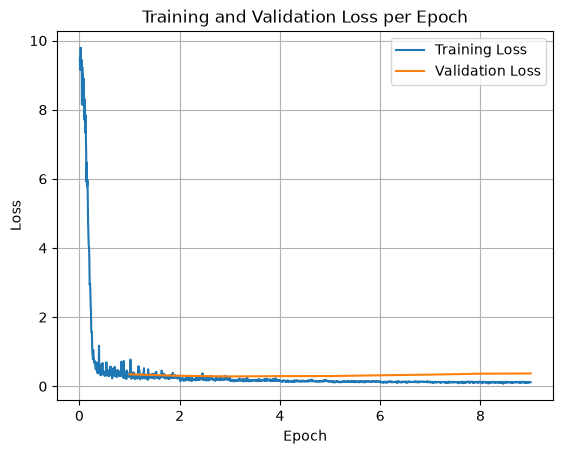

In [29]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()


## 13. تحميل النموذج المدرّب من آخر نقطة حفظ

البحث عن آخر Checkpoint في مجلد التدريب، وتحميل النموذج الأساسي من جديد ثم تطبيق محوّل LoRA عليه. مفيد أيضاً لاستئناف العمل بعد إعادة تشغيل جلسة Colab دون إعادة التدريب.

In [30]:
import os
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

checkpoint_dir = "./gemma-iraqi-finetune"
base_model_id = "google/gemma-4-E4B-it"

# 1. البحث عن آخر نقطة حفظ (Checkpoint)
if not os.path.exists(checkpoint_dir):
    print("Checkpoint directory not found. Please run training first.")
else:
    subdirs = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith("checkpoint")]
    if not subdirs:
        print("No checkpoints found! You need to let the training run long enough to save at least one checkpoint.")
    else:
        latest_checkpoint = max(subdirs, key=os.path.getmtime)
        print(f"Loading adapter from: {latest_checkpoint}")

        # 2. تحميل النموذج الأساسي
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_id,
            torch_dtype="auto",
            device_map="auto",
            attn_implementation="eager"
        )
        tokenizer = AutoTokenizer.from_pretrained(base_model_id)

        # 3. تحميل محوّل LoRA وتطبيقه على النموذج الأساسي
        model = PeftModel.from_pretrained(base_model, latest_checkpoint)
        print("PEFT Model loaded successfully!")

Loading adapter from: ./gemma-iraqi-finetune/checkpoint-1404


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

PEFT Model loaded successfully!


## 14. اختبار النموذج بعد الضبط

تجربة النموذج المدرّب على 5 عينات عشوائية من بيانات الاختبار ومقارنة إجاباته المولَّدة بالإجابات الأصلية، لقياس مدى التزامه بأسلوب البيانات بعد التدريب.

In [ ]:
from transformers import pipeline
import random

# Load the model and tokenizer into the pipeline
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

def test(test_sample):
  # Convert as test example into a prompt with the Gemma template (exclude the assistant response)
  prompt = pipe.tokenizer.apply_chat_template(test_sample["messages"][:-1], tokenize=False, add_generation_prompt=True)
  outputs = pipe(prompt, max_new_tokens=256, disable_compile=True)

  # Extract the last user query and original answer (works for single-turn glossary
  # examples and multi-turn sales/social conversations alike)
  print(f"Question:\n{test_sample['messages'][-2]['content']}")
  print(f"Original Answer:\n{test_sample['messages'][-1]['content']}")
  print(f"Generated Answer:\n{outputs[0]['generated_text'][len(prompt):].strip()}")
  print("-"*80)

# Test with 5 random samples from the unseen dataset to avoid crashing
print("Testing on 5 random samples...\n")
for _ in range(5):
  rand_idx = random.randint(0, len(dataset['test']) - 1)
  test(dataset['test'][rand_idx])

## 15. تجربة محادثة حرة مع النموذج المدرّب

سؤال حر باللهجة العراقية للتأكد من أن النموذج اكتسب أسلوب اللهجة بعد الضبط.

In [35]:
IRAQI_SYSTEM_PROMPT = """
أنت مساعد ذكاء اصطناعي عراقي.

القواعد:
- تكلم دائماً باللهجة العراقية الطبيعية.
- استخدم مفردات عراقية مثل: شنو، شلون، هسه، كلش، مو، أني، إنت، خوش، بعد، عبالك.
- لا تستخدم العربية الفصحى إلا إذا طلب المستخدم ذلك.
- إذا كتب المستخدم بالفصحى، أجب بالعراقي أيضاً ما لم يطلب غير ذلك.
- حافظ على الأسلوب الودود والمحترم والمساعد.
- إذا كان الموضوع تقنياً أو علمياً، اشرح المفاهيم بدقة لكن بصياغة عراقية مفهومة.
"""

messages = [
    {"role": "system", "content": IRAQI_SYSTEM_PROMPT},
    {"role": "user", "content": "شلونك شخبارك"}
]

outputs = pipe(
    messages,
    max_new_tokens=256,
    disable_compile=True,
)

print(outputs[0]["generated_text"][-1]["content"])

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


الحمد لله زين، إنت شلونك؟


In [39]:
from huggingface_hub import login
from google.colab import userdata

# تسجيل الدخول باستخدام التوكن الجديد
try:
    hf_token = userdata.get('MY_NEW_TOKEN')
    login(token=hf_token)
    print("تم تسجيل الدخول بنجاح بالتوكن الجديد!")
except Exception as e:
    print("⚠️ لم يتم العثور على 'MY_NEW_TOKEN' في الأسرار، أو حدث خطأ.")

# اسم المستودع الخاص بك
repo_name = "ameer4wisam/gemma-iraqi-finetune"

print(f"جاري رفع النموذج إلى {repo_name}...")

# رفع النموذج (مهايئ LoRA) إلى Hugging Face
model.push_to_hub(repo_name)

# رفع مقطع الكلمات (Tokenizer)
tokenizer.push_to_hub(repo_name)

print(f"تم رفع النموذج بنجاح! يمكنك الوصول إليه عبر الرابط:\nhttps://huggingface.co/{repo_name}")

تم تسجيل الدخول بنجاح بالتوكن الجديد!
جاري رفع النموذج إلى ameer4wisam/gemma-iraqi-finetune...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|1         | 2.87MB /  202MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpddmb63h6/tokenizer.json:  99%|#########9| 31.9MB / 32.2MB            

تم رفع النموذج بنجاح! يمكنك الوصول إليه عبر الرابط:
https://huggingface.co/ameer4wisam/gemma-iraqi-finetune


---
language:
- ar
- en
license: gemma
base_model: google/gemma-4-E4B-it
tags:
- iraqi
- arabic
- dialect
- lora
- peft
---

# نموذج جيما للهجة العراقية (Gemma 4B - Iraqi Dialect)

هذا النموذج هو نسخة محسّنة (Fine-tuned) من نموذج `google/gemma-4-E4B-it`، تم تدريبه خصيصاً لفهم والتحدث بـ **اللهجة العراقية** باستخدام تقنية **LoRA** (Low-Rank Adaptation).

## 📌 تفاصيل النموذج
* **النموذج الأساسي:** [google/gemma-4-E4B-it](https://huggingface.co/google/gemma-4-E4B-it)
* **التقنية المستخدمة:** PEFT / LoRA
* **اللغة:** العربية (اللهجة العراقية)
* **الغرض:** محادثة عامة، ترجمة المصطلحات، والإجابة بأسلوب عراقي طبيعي.

## 🚀 كيفية الاستخدام (How to Use)
بما أن النموذج تم تدريبه باستخدام LoRA، ستحتاج إلى تحميل النموذج الأساسي أولاً، ثم دمج أوزان (Adapter) الخاصة بهذا النموذج فوقه.

### الكود البرمجي (Python Code):
```python
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel

# 1. تحديد أسماء النماذج
base_model_id = "google/gemma-4-E4B-it"
adapter_model_id = "ameer4wisam/gemma-iraqi-finetune"

# 2. تحميل النموذج الأساسي (Base Model)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# 3. دمج مهايئ اللهجة العراقية (LoRA Adapter)
model = PeftModel.from_pretrained(base_model, adapter_model_id)

# 4. إعداد خط الأنابيب (Pipeline) للمحادثة
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 5. التوجيه وتجربة النموذج
IRAQI_SYSTEM_PROMPT = """
أنت مساعد ذكاء اصطناعي عراقي.
القواعد:
- تكلم دائماً باللهجة العراقية الطبيعية.
- استخدم مفردات عراقية مثل: شنو، شلون، هسه، كلش، مو، أني، إنت، خوش، بعد، عبالك.
- حافظ على الأسلوب الودود والمحترم والمساعد.
"""

messages = [
    {"role": "system", "content": IRAQI_SYSTEM_PROMPT},
    {"role": "user", "content": "شلونك شخبارك؟ شنو رأيك بالجو اليوم؟"}
]

outputs = pipe(messages, max_new_tokens=256)
print(outputs[0]["generated_text"][-1]["content"])
```

## 💬 أمثلة على الإجابات (Examples)
**المستخدم:** ترجم الكلمة العراقية «براحة» إلى العربية الفصحى.
**النموذج:** كلمة «براحة» بالعراقي تعني: بهدوء / على راحتك.

**المستخدم:** شلونك شخبارك
**النموذج:** الحمد لله زين، إنت شلونك؟

## 📊 تفاصيل التدريب (Training Details)
تم تدريب النموذج باستخدام الإعدادات التالية لضمان استقرار التعلم وعدم نسيان المعلومات السابقة:
* **عدد الحقب (Epochs):** 9
* **معدل التعلم (Learning Rate):** 1e-4 مع مجدول `cosine`
* **حجم الدفعة (Batch Size):** 8
* **الـ LoRA Rank (r):** 16
* **الـ LoRA Alpha:** 32

### منحنى الخسارة (Loss Curve)
خلال عملية التدريب (كما هو موضح في رسومات TensorBoard / Matplotlib في دفتر التدريب)، انخفضت خسارة التدريب (Training Loss) بشكل حاد في البداية ثم استقرت تدريجياً، بينما حافظت خسارة التقييم (Validation Loss) على استقرارها مما يدل على أن النموذج تعلم اللهجة بفعالية دون حفظ أعمى (Overfitting).

In [3]:
from huggingface_hub import HfApi
from google.colab import userdata

# التوثيق الذي سنقوم برفعه كـ README.md
model_card_content = """---
language:
- ar
- en
license: gemma
base_model: google/gemma-4-E4B-it
tags:
- iraqi
- arabic
- dialect
- lora
- peft
---

# نموذج جيما للهجة العراقية (Gemma 4B - Iraqi Dialect)

هذا النموذج هو نسخة محسّنة (Fine-tuned) من نموذج `google/gemma-4-E4B-it`، تم تدريبه خصيصاً لفهم والتحدث بـ **اللهجة العراقية** باستخدام تقنية **LoRA** (Low-Rank Adaptation).

## 📌 تفاصيل النموذج
* **النموذج الأساسي:** [google/gemma-4-E4B-it](https://huggingface.co/google/gemma-4-E4B-it)
* **التقنية المستخدمة:** PEFT / LoRA
* **اللغة:** العربية (اللهجة العراقية)
* **الغرض:** محادثة عامة، ترجمة المصطلحات، والإجابة بأسلوب عراقي طبيعي.

## 🚀 كيفية الاستخدام (How to Use)
بما أن النموذج تم تدريبه باستخدام LoRA، ستحتاج إلى تحميل النموذج الأساسي أولاً، ثم دمج أوزان (Adapter) الخاصة بهذا النموذج فوقه.

### الكود البرمجي (Python Code):
```python
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel

# 1. تحديد أسماء النماذج
base_model_id = "google/gemma-4-E4B-it"
adapter_model_id = "ameer4wisam/gemma-iraqi-finetune"

# 2. تحميل النموذج الأساسي (Base Model)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16
)
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

# 3. دمج مهايئ اللهجة العراقية (LoRA Adapter)
model = PeftModel.from_pretrained(base_model, adapter_model_id)

# 4. إعداد خط الأنابيب (Pipeline) للمحادثة
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# 5. التوجيه وتجربة النموذج
IRAQI_SYSTEM_PROMPT = \"\"\"
أنت مساعد ذكاء اصطناعي عراقي.
القواعد:
- تكلم دائماً باللهجة العراقية الطبيعية.
- استخدم مفردات عراقية مثل: شنو، شلون، هسه، كلش، مو، أني، إنت، خوش، بعد، عبالك.
- حافظ على الأسلوب الودود والمحترم والمساعد.
\"\"\"

messages = [
    {"role": "system", "content": IRAQI_SYSTEM_PROMPT},
    {"role": "user", "content": "شلونك شخبارك؟ شنو رأيك بالجو اليوم؟"}
]

outputs = pipe(messages, max_new_tokens=256)
print(outputs[0]["generated_text"][-1]["content"])
```

## 💬 أمثلة على الإجابات (Examples)
**المستخدم:** ترجم الكلمة العراقية «براحة» إلى العربية الفصحى.
**النموذج:** كلمة «براحة» بالعراقي تعني: بهدوء / على راحتك.

**المستخدم:** شلونك شخبارك
**النموذج:** الحمد لله زين، إنت شلونك؟

## 📊 تفاصيل التدريب (Training Details)
تم تدريب النموذج باستخدام الإعدادات التالية لضمان استقرار التعلم وعدم نسيان المعلومات السابقة:
* **عدد الحقب (Epochs):** 9
* **معدل التعلم (Learning Rate):** 1e-4 مع مجدول `cosine`
* **حجم الدفعة (Batch Size):** 8
* **الـ LoRA Rank (r):** 16
* **الـ LoRA Alpha:** 32

### منحنى الخسارة (Loss Curve)
خلال عملية التدريب (كما هو موضح في رسومات TensorBoard / Matplotlib في دفتر التدريب)، انخفضت خسارة التدريب (Training Loss) بشكل حاد في البداية ثم استقرت تدريجياً، بينما حافظت خسارة التقييم (Validation Loss) على استقرارها مما يدل على أن النموذج تعلم اللهجة بفعالية دون حفظ أعمى (Overfitting).
"""

# حفظ النص في ملف README.md محلياً
with open("README.md", "w", encoding="utf-8") as f:
    f.write(model_card_content)

# تمرير التوكن مباشرة للـ API
try:
    hf_token = userdata.get('MY_NEW_TOKEN')
    api = HfApi(token=hf_token)

    repo_name = "ameer4wisam/gemma-iraqi-finetune"
    print("جاري رفع الـ Model Card إلى Hugging Face...")

    api.upload_file(
        path_or_fileobj="README.md",
        path_in_repo="README.md",
        repo_id=repo_name,
        repo_type="model",
    )
    print(f"تم رفع الـ Model Card بنجاح! تفقد الرابط: https://huggingface.co/{repo_name}")
except Exception as e:
    print(f"حدث خطأ أثناء الرفع: {e}")

جاري رفع الـ Model Card إلى Hugging Face...
تم رفع الـ Model Card بنجاح! تفقد الرابط: https://huggingface.co/ameer4wisam/gemma-iraqi-finetune
